## 1) Import Libraries

In [1]:
# Import operating-system and path tools.
import os
from pathlib import Path

# Import warning control tools.
import warnings

# Hide unnecessary warning messages.
warnings.filterwarnings("ignore")

# Import numerical computing tools.
import numpy as np

# Import tabular data tools.
import pandas as pd

# Import plotting tools.
import matplotlib.pyplot as plt

# Import scientific-statistics tools.
from scipy import stats

# Import train/test splitting tools.
from sklearn.model_selection import train_test_split

# Import preprocessing tools.
from sklearn.preprocessing import StandardScaler

# Import tree-based models for feature importance.
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

# Import evaluation metrics.
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Import class-weight utility for imbalanced classes.
from sklearn.utils.class_weight import compute_class_weight

# Try to import TensorFlow for ANN modeling.
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    print("TensorFlow version:", tf.__version__)
except Exception as error:
    print("TensorFlow could not be imported. Install tensorflow before running ANN cells.")
    print("Import error:", error)

# Set the random seed for reproducible NumPy behavior.
np.random.seed(42)

# Set the random seed for reproducible TensorFlow behavior when TensorFlow is available.
try:
    tf.random.set_seed(42)
except Exception:
    pass


TensorFlow version: 2.20.0


## 2) Load, Shuffle, and Initial EDA

In [6]:
# Store the dataset file name.
DATA_FILE = "1-spotify.csv"

# Create a list of possible dataset locations.
possible_paths = [
    Path("datasets") / DATA_FILE,
    Path("../datasets") / DATA_FILE,
    Path("/mnt/data") / DATA_FILE,
    Path(DATA_FILE),  # current working directory
]

# Find the first existing path.
DATA_PATH = next((path for path in possible_paths if path.exists()), None)

# Stop execution if the dataset file is not found.
if DATA_PATH is None:
    raise FileNotFoundError(f"Dataset file was not found: {DATA_FILE}")

# Load the dataset into a DataFrame.
df_raw = pd.read_csv(DATA_PATH)

# Shuffle the full dataset with a fixed seed.
df = df_raw.sample(frac=1, random_state=42).reset_index(drop=True)

# Display the selected file path.
print("Loaded dataset from:", DATA_PATH)

# Display the shape of the shuffled dataset.
print("Dataset shape:", df.shape)

# Display the first rows of the dataset.
display(df.head())


Loaded dataset from: 1-spotify.csv
Dataset shape: (2010, 17)


,track_id,track_name,artist_name,genre,key,mode,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity
0,TRK001197,Track_1197,Artist_250,pop,3,1,0.2211,0.6200,-9.800,0.1928,0.3201,0.0530,0.0741,0.3965,90.96,282415,52
1,TRK000527,Track_0527,Artist_323,rock,0,1,0.6232,0.5152,-13.720,0.1563,0.3864,0.0457,0.1099,0.4526,138.45,202991,51
2,TRK000394,Track_0394,Artist_210,pop,6,0,0.8207,0.6641,-9.746,0.2835,0.0000,0.1022,0.1071,0.8812,166.22,212761,70
3,TRK001405,Track_1405,Artist_062,country,5,1,0.8261,0.7156,-8.053,0.0833,0.2987,0.1183,0.1569,0.6240,137.41,178671,54
4,TRK000434,Track_0434,Artist_046,pop,4,1,0.9515,0.4894,-16.333,0.2096,0.6891,0.1453,0.1470,0.5303,128.80,226412,64


Columns:
['track_id', 'track_name', 'artist_name', 'genre', 'key', 'mode', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'popularity']

Data types:


track_id             object
track_name           object
artist_name          object
genre                object
key                   int64
mode                  int64
danceability        float64
energy              float64
loudness            float64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms           int64
popularity            int64
dtype: object


Missing values:


,missing_count,missing_percent
genre,32,1.59
instrumentalness,31,1.54
acousticness,31,1.54
speechiness,30,1.49
track_name,30,1.49
loudness,30,1.49
energy,30,1.49
artist_name,30,1.49
danceability,30,1.49
track_id,0,0.00



Duplicate rows: 10

Numerical description:


,count,mean,std,min,25%,50%,75%,max
key,2010.0,5.308458,3.443547,0.000000,2.000000,5.00000,8.000000,11.000000
mode,2010.0,0.502488,0.500118,0.000000,0.000000,1.00000,1.000000,1.000000
danceability,1980.0,0.624478,0.184214,-0.775541,0.515375,0.63435,0.751625,1.996613
energy,1980.0,0.574418,0.198853,-0.953501,0.450475,0.57545,0.708825,2.016007
loudness,1980.0,-11.407809,4.907520,-44.177204,-14.512000,-11.19150,-8.202250,25.450673
speechiness,1980.0,0.167865,0.116589,-0.693580,0.087775,0.15255,0.225125,1.000586
acousticness,1979.0,0.428228,0.239851,0.000000,0.250850,0.42110,0.592600,1.000000
instrumentalness,1979.0,0.127094,0.107416,0.000200,0.044450,0.09960,0.180550,0.703000
liveness,2010.0,0.238564,0.124316,0.005700,0.140900,0.22265,0.319175,0.777600
valence,2010.0,0.526090,0.198570,0.000000,0.393000,0.52255,0.661375,1.000000


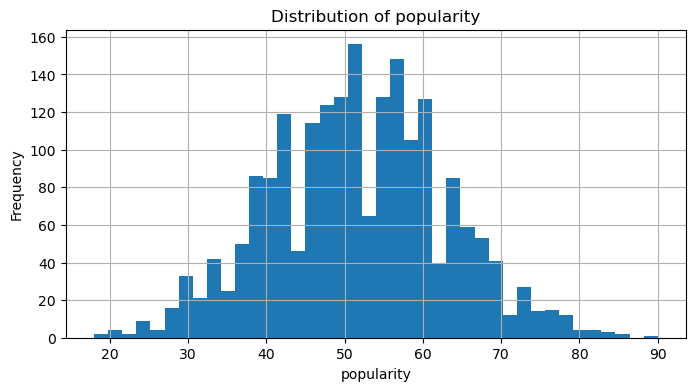

In [7]:
# Display basic column information.
print("Columns:")
print(df.columns.tolist())

# Display data types for all columns.
print("\nData types:")
display(df.dtypes)

# Count missing values in each column.
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100).round(2)
}).sort_values("missing_count", ascending=False)

# Display the missing-value summary.
print("\nMissing values:")
display(missing_summary)

# Count duplicate rows.
duplicate_count = df.duplicated().sum()

# Display duplicate-row count.
print("\nDuplicate rows:", duplicate_count)

# Display descriptive statistics for numerical columns.
print("\nNumerical description:")
display(df.describe().T)

# Plot the target-score distribution.
plt.figure(figsize=(8, 4))
df["popularity"].hist(bins=40)
plt.title("Distribution of popularity")
plt.xlabel("popularity")
plt.ylabel("Frequency")
plt.show()


## 3) Feature Importance and Driver Feature Selection

Selected driver feature: valence


,importance
valence,0.182408
danceability,0.165629
energy,0.130177
loudness,0.079655
instrumentalness,0.071892
speechiness,0.068945
tempo,0.068126
liveness,0.067802
acousticness,0.062811
duration_ms,0.058227


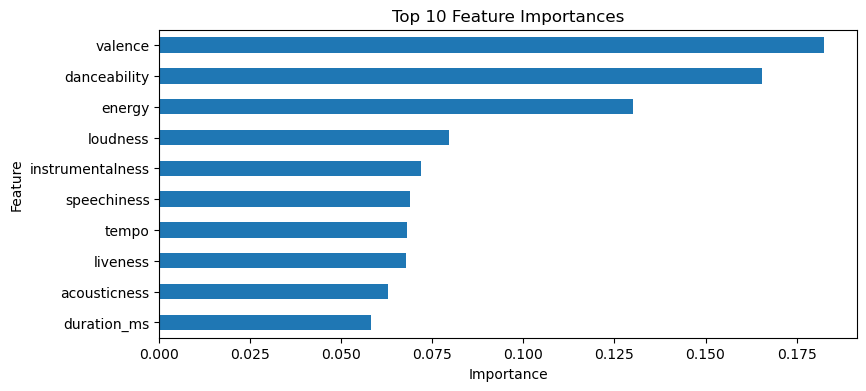

In [8]:
# Define the continuous target column used for feature-importance discovery.
target_col = "popularity"

# Define metadata columns that should not be used for feature-importance modeling.
metadata_cols = ['track_id', 'track_name', 'artist_name', 'index']

# Select numerical columns only for reliable tree-based feature ranking.
numeric_candidate_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove the target and metadata columns from numerical candidates.
numeric_feature_cols = [col for col in numeric_candidate_cols if col not in metadata_cols + [target_col]]

# Create a clean temporary frame for feature-importance analysis.
fi_frame = df[numeric_feature_cols + [target_col]].copy()

# Fill missing numerical values with median values.
for col in numeric_feature_cols + [target_col]:
    fi_frame[col] = fi_frame[col].fillna(fi_frame[col].median())

# Separate features and target.
X_fi = fi_frame[numeric_feature_cols]
y_fi = fi_frame[target_col]

# Limit the sample size to keep feature-importance computation fast.
sample_size = min(10000, len(X_fi))

# Sample rows for the tree-based feature-importance model.
X_fi_sample = X_fi.sample(sample_size, random_state=42)
y_fi_sample = y_fi.loc[X_fi_sample.index]

# Build a Random Forest regressor for feature importance.
fi_model = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)

# Fit the feature-importance model.
fi_model.fit(X_fi_sample, y_fi_sample)

# Store feature importances in a sorted Series.
feature_importance = pd.Series(fi_model.feature_importances_, index=numeric_feature_cols).sort_values(ascending=False)

# Select the strongest numerical driver feature.
driver_feature = feature_importance.index[0]

# Display the selected driver feature.
print("Selected driver feature:", driver_feature)

# Display the top 10 features.
display(feature_importance.head(10).to_frame("importance"))

# Plot the top 10 feature importances.
plt.figure(figsize=(9, 4))
feature_importance.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## 4) Multicollinearity Audit

,key,mode,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity
key,1.00,-0.01,0.03,-0.03,-0.03,-0.01,0.02,-0.01,-0.03,0.03,0.02,-0.02,-0.00
mode,-0.01,1.00,0.01,0.00,0.02,-0.00,-0.00,-0.03,-0.02,0.01,-0.01,-0.00,0.01
danceability,0.03,0.01,1.00,-0.04,0.00,0.02,0.05,-0.00,0.02,0.31,0.02,0.02,0.32
energy,-0.03,0.00,-0.04,1.00,0.67,0.04,-0.60,0.00,0.02,0.24,0.00,-0.02,0.29
loudness,-0.03,0.02,0.00,0.67,1.00,0.03,-0.53,-0.01,0.02,0.25,0.03,-0.01,0.27
speechiness,-0.01,-0.00,0.02,0.04,0.03,1.00,-0.03,-0.01,0.04,0.00,0.02,0.00,0.03
acousticness,0.02,-0.00,0.05,-0.60,-0.53,-0.03,1.00,-0.00,-0.01,-0.18,-0.03,0.02,-0.22
instrumentalness,-0.01,-0.03,-0.00,0.00,-0.01,-0.01,-0.00,1.00,0.03,0.01,-0.04,0.02,-0.10
liveness,-0.03,-0.02,0.02,0.02,0.02,0.04,-0.01,0.03,1.00,0.03,-0.02,0.03,0.01
valence,0.03,0.01,0.31,0.24,0.25,0.00,-0.18,0.01,0.03,1.00,0.03,-0.01,0.38


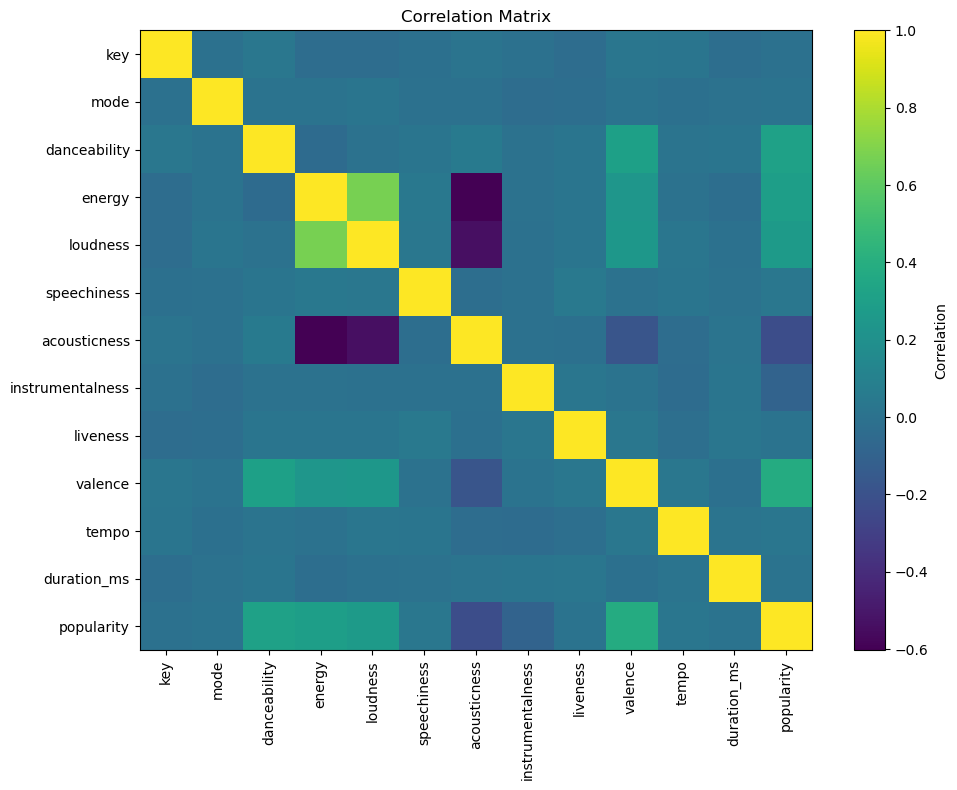

Highly correlated pairs with |correlation| > 0.85:


,feature_a,feature_b,correlation


Redundant-feature candidates: []


In [9]:
# Build a numerical correlation matrix.
corr_matrix = df[numeric_feature_cols + [target_col]].corr(numeric_only=True)

# Display the correlation matrix.
display(corr_matrix.round(2))

# Plot the correlation matrix with matplotlib.
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Find highly correlated feature pairs.
high_corr_pairs = []

# Loop over the upper triangle of the correlation matrix.
for i, col_a in enumerate(corr_matrix.columns):
    for col_b in corr_matrix.columns[i + 1:]:
        if col_a != target_col and col_b != target_col:
            corr_value = corr_matrix.loc[col_a, col_b]
            if abs(corr_value) > 0.85:
                high_corr_pairs.append((col_a, col_b, corr_value))

# Display highly correlated pairs.
print("Highly correlated pairs with |correlation| > 0.85:")
display(pd.DataFrame(high_corr_pairs, columns=["feature_a", "feature_b", "correlation"]))

# Create a simple list of redundant columns to drop later.
redundant_features = list({pair[1] for pair in high_corr_pairs})

# Display redundant-feature candidates.
print("Redundant-feature candidates:", redundant_features)


## 5) Creating a Three-Class Target and Full Preprocessing

In [10]:
# Create a working copy of the shuffled dataset.
work = df.copy()

# Drop exact duplicate rows.
work = work.drop_duplicates().reset_index(drop=True)

# Fill missing values in popularity and driver feature before labeling.
work["popularity"] = work["popularity"].fillna(work["popularity"].median())
work[driver_feature] = work[driver_feature].fillna(work[driver_feature].median())

# Compute the 70th percentile of popularity.
popularity_top = work["popularity"].quantile(0.70)

# Compute the 70th percentile of the selected driver feature.
driver_top = work[driver_feature].quantile(0.70)

# Compute the median of popularity.
popularity_median = work["popularity"].median()

# Compute the median of the selected driver feature.
driver_median = work[driver_feature].median()

# Create boolean masks for high popularity and high driver-feature value.
high_popularity = work["popularity"] >= popularity_top
high_driver = work[driver_feature] >= driver_top
low_popularity = work["popularity"] < popularity_median
low_driver = work[driver_feature] < driver_median

# Create the 3-class target using composite feature-driven logic.
work["target_class"] = np.select(
    [high_popularity & high_driver, high_popularity | high_driver, low_popularity & low_driver],
    [2, 1, 0],
    default=1
).astype(int)

# Fill numeric missing values with median values.
for col in work.select_dtypes(include=[np.number]).columns:
    work[col] = work[col].fillna(work[col].median())

# Fill categorical missing values with mode values.
for col in work.select_dtypes(exclude=[np.number]).columns:
    work[col] = work[col].fillna(work[col].mode(dropna=True)[0])

# Select numerical columns for Z-score outlier filtering.
outlier_cols = [col for col in work.select_dtypes(include=[np.number]).columns if col not in ["target_class", "popularity"]]

# Compute absolute Z-scores for selected columns.
z_scores = np.abs(stats.zscore(work[outlier_cols], nan_policy="omit"))

# Keep rows where every selected numerical feature has |Z| < 3.
work = work[(z_scores < 3).all(axis=1)].reset_index(drop=True)

# Create cyclical encoding for musical key.
work["key_sin"] = np.sin(2 * np.pi * work["key"] / 12)
work["key_cos"] = np.cos(2 * np.pi * work["key"] / 12)

# Drop the original key column after cyclical encoding.
work = work.drop(columns=["key"], errors="ignore")

# Store genre frequencies for later simulation.
genre_frequency_map = work["genre"].value_counts(normalize=True).to_dict()

# Apply frequency encoding to genre.
work["genre_frequency"] = work["genre"].map(genre_frequency_map)

# Drop the original genre column after encoding.
work = work.drop(columns=["genre"], errors="ignore")

# Create an engineered feature combining energy and loudness.
work["energy_loudness_ratio"] = work["energy"] / (np.abs(work["loudness"]) + 1)

# Drop metadata columns and direct target-score column.
feature_drop_cols = ["track_id", "track_name", "artist_name", "index", "popularity", "target_class"]

# Create the feature matrix.
X = work.drop(columns=feature_drop_cols, errors="ignore")

# Create the label vector.
y = work["target_class"].astype(int)

# Keep only numerical columns after all encodings.
X = X.select_dtypes(include=[np.number])

# Store final feature names for simulation.
feature_columns = X.columns.tolist()

# Split data into train+validation and test sets.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Split train+validation into train and validation sets.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42, stratify=y_train_val
)

# Create a StandardScaler object.
scaler = StandardScaler()

# Fit the scaler only on training features.
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation features using the training scaler.
X_val_scaled = scaler.transform(X_val)

# Transform test features using the training scaler.
X_test_scaled = scaler.transform(X_test)

# Display final shapes.
print("X_train:", X_train_scaled.shape)
print("X_val:", X_val_scaled.shape)
print("X_test:", X_test_scaled.shape)
print("Class distribution:")
display(y.value_counts(normalize=True).sort_index())


X_train: (1325, 15)
X_val: (284, 15)
X_test: (285, 15)
Class distribution:


target_class
0    0.308342
1    0.540127
2    0.151531
Name: proportion, dtype: float64

## 6) ANN Design, Training, and Evaluation

In [11]:
# Define a helper function to compute class weights.
def make_class_weights(y_train):
    # Get sorted unique class labels.
    classes = np.unique(y_train)
    
    # Compute balanced class weights.
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    
    # Convert class weights to a dictionary expected by Keras.
    return dict(zip(classes, weights))

# Define reusable callbacks for stable ANN training.
def make_callbacks():
    # Stop training when validation loss stops improving.
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )
    
    # Reduce learning rate when validation accuracy plateaus.
    reduce_lr = ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
    
    # Return the callback list.
    return [early_stop, reduce_lr]

# Define a helper function to plot loss curves.
def plot_history(history, title):
    # Create a figure for the loss curve.
    plt.figure(figsize=(8, 4))
    
    # Plot training loss.
    plt.plot(history.history["loss"], label="Training loss")
    
    # Plot validation loss.
    plt.plot(history.history["val_loss"], label="Validation loss")
    
    # Add labels and title.
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

# Define a helper function for test evaluation.
def evaluate_model(model, X_test, y_test, class_names=None):
    # Predict class probabilities.
    y_proba = model.predict(X_test)
    
    # Convert probabilities to predicted class ids.
    y_pred = np.argmax(y_proba, axis=1)
    
    # Print accuracy and macro F1 score.
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
    
    # Print the classification report.
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=class_names))
    
    # Create the confusion matrix.
    cm = confusion_matrix(y_test, y_pred, normalize="true")
    
    # Plot the normalized confusion matrix.
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(values_format=".2f")
    plt.title("Normalized Confusion Matrix")
    plt.show()
    
    # Return predictions for additional analysis.
    return y_pred, y_proba



Epoch 1/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3182 - loss: 1.6958 - val_accuracy: 0.4401 - val_loss: 1.0451 - learning_rate: 0.0010
Epoch 2/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5303 - loss: 1.2833 - val_accuracy: 0.4930 - val_loss: 1.0059 - learning_rate: 0.0010
Epoch 3/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5606 - loss: 0.9971 - val_accuracy: 0.5599 - val_loss: 0.9755 - learning_rate: 0.0010
Epoch 4/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6364 - loss: 0.7520 - val_accuracy: 0.5599 - val_loss: 0.9544 - learning_rate: 0.0010
Epoch 5/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6667 - loss: 0.5890 - val_accuracy: 0.5528 - val_loss: 0.9391 - learning_rate: 0.0010
Epoch 6/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6667 - loss: 0.6607 - val_accuracy: 0.5669 - val_loss: 0.9275 - learning_rate: 0.0010
Epoch 7/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6667 - loss: 0.5654 - val_accuracy: 0.5423 -

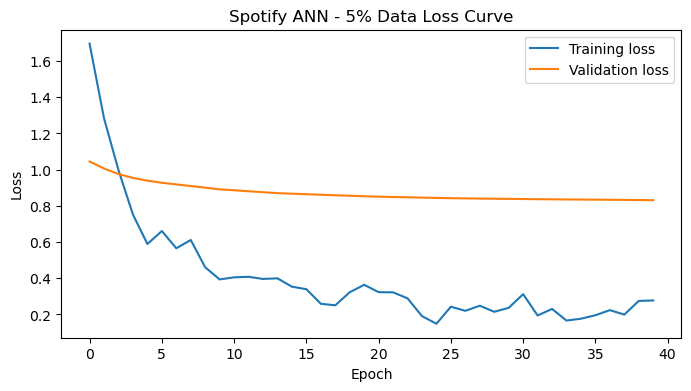

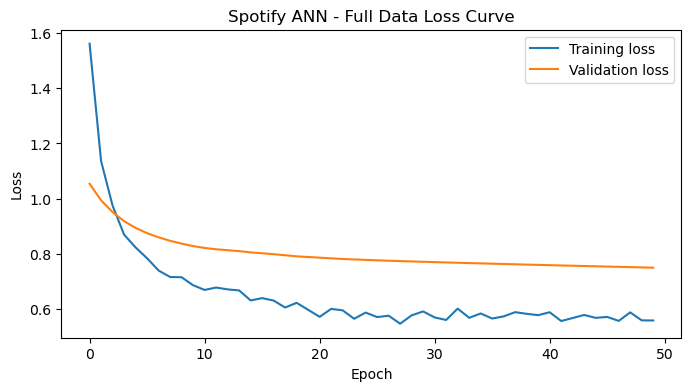

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Accuracy: 0.7368421052631579
Macro F1: 0.7344682642473136

Classification report:
              precision    recall  f1-score   support

         Low       0.73      0.75      0.74        88
      Medium       0.79      0.69      0.74       154
         Hit       0.63      0.86      0.73        43

    accuracy                           0.74       285
   macro avg       0.71      0.77      0.73       285
weighted avg       0.75      0.74      0.74       285



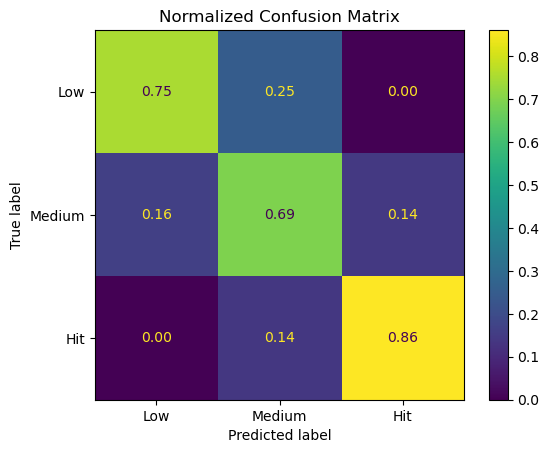

In [12]:
# Define the Spotify ANN architecture.
def build_spotify_ann(input_dim):
    # Clear previous Keras graph state.
    tf.keras.backend.clear_session()
    
    # Create a sequential model.
    model = Sequential()
    
    # Add the input-aware first dense layer.
    model.add(Dense(512, input_shape=(input_dim,)))
    
    # Add LeakyReLU activation for stable gradients.
    model.add(LeakyReLU(alpha=0.1))
    
    # Add batch normalization for training stability.
    model.add(BatchNormalization())
    
    # Add dropout to reduce overfitting.
    model.add(Dropout(0.30))
    
    # Add the second dense layer.
    model.add(Dense(256, activation="tanh"))
    
    # Add batch normalization after the second layer.
    model.add(BatchNormalization())
    
    # Add dropout after the second layer.
    model.add(Dropout(0.25))
    
    # Add the third dense layer.
    model.add(Dense(64))
    
    # Add LeakyReLU activation.
    model.add(LeakyReLU(alpha=0.1))
    
    # Add dropout after the refinement layer.
    model.add(Dropout(0.20))
    
    # Add the softmax output layer for 3 classes.
    model.add(Dense(3, activation="softmax", dtype="float32"))
    
    # Compile the model.
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    # Return the compiled model.
    return model

# Compute class weights for imbalanced classes.
class_weights = make_class_weights(y_train)

# Create a 5-percent subset for the baseline scale experiment.
subset_size = max(50, int(len(X_train_scaled) * 0.05))

# Select subset rows.
X_subset = X_train_scaled[:subset_size]
y_subset = y_train.iloc[:subset_size]

# Build the subset model.
subset_model = build_spotify_ann(X_train_scaled.shape[1])

# Train the subset model.
history_subset = subset_model.fit(
    X_subset,
    y_subset,
    validation_data=(X_val_scaled, y_val),
    epochs=40,
    batch_size=256,
    callbacks=make_callbacks(),
    class_weight=make_class_weights(y_subset),
    verbose=1
)

# Build the full-scale model.
full_model = build_spotify_ann(X_train_scaled.shape[1])

# Train the full-scale model.
history_full = full_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=2048,
    callbacks=make_callbacks(),
    class_weight=class_weights,
    verbose=1
)

# Plot loss curves for the subset scenario.
plot_history(history_subset, "Spotify ANN - 5% Data Loss Curve")

# Plot loss curves for the full-data scenario.
plot_history(history_full, "Spotify ANN - Full Data Loss Curve")

# Evaluate the full model on the test set.
y_pred, y_proba = evaluate_model(full_model, X_test_scaled, y_test, class_names=["Low", "Medium", "Hit"])


## 7) Simulation Function for a New Track

In [15]:
# Define a simulation function for a hypothetical new song.
def simulate_new_song(raw_song):
    # Convert the raw dictionary into a one-row DataFrame.
    song = pd.DataFrame([raw_song])
    
    # Fill missing numerical values using training medians from X.
    for col in song.select_dtypes(include=[np.number]).columns:
        song[col] = song[col].fillna(work[col].median() if col in work.columns else 0)
    
    # Encode key cyclically when key exists.
    if "key" in song.columns:
        song["key_sin"] = np.sin(2 * np.pi * song["key"] / 12)
        song["key_cos"] = np.cos(2 * np.pi * song["key"] / 12)
        song = song.drop(columns=["key"], errors="ignore")
    
    # Apply stored genre-frequency encoding.
    if "genre" in song.columns:
        song["genre_frequency"] = song["genre"].map(genre_frequency_map).fillna(0)
        song = song.drop(columns=["genre"], errors="ignore")
    
    # Create the engineered ratio feature when required columns exist.
    if "energy" in song.columns and "loudness" in song.columns:
        song["energy_loudness_ratio"] = song["energy"] / (np.abs(song["loudness"]) + 1)
    
    # Remove metadata and target-related columns.
    song = song.drop(columns=["track_id", "track_name", "artist_name", "index", "popularity"], errors="ignore")
    
    # Reindex columns to match training features.
    song = song.reindex(columns=feature_columns, fill_value=0)
    
    # Scale the new song with the training scaler.
    song_scaled = scaler.transform(song)
    
    # Predict class probabilities.
    probabilities = full_model.predict(song_scaled)[0]
    
    # Return probabilities as a readable Series.
    return pd.Series(probabilities, index=["Low", "Medium", "Hit"])

# Example raw song for simulation.
example_song = {
    "genre": "pop",
    "key": 5,
    "mode": 1,
    "danceability": 0.72,
    "energy": 0.81,
    "loudness": -5.8,
    "speechiness": 0.06,
    "acousticness": 0.18,
    "instrumentalness": 0.01,
    "liveness": 0.12,
    "valence": 0.65,
    "tempo": 124,
    "duration_ms": 210000
}

# Run the simulation.
simulate_new_song(example_song)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


Low       0.083698
Medium    0.442913
Hit       0.473389
dtype: float32